# Full Experiment Pipeline Gate

This notebook runs the real foundation-model experiment pipeline sequentially on your local machine or a GPU VM.

Current default mode is a controlled Mac pilot:

- dataset: `ftw_africa`
- models: `prithvi_eo_v2_300m`, `terramind_v1_base`, `terramind_v1_large`
- adapters: `linear_probe`, `lora`
- label budgets: `0.10`, `0.25`
- one seed: `1234`
- eight train batches and eight validation batches per cell

The notebook loads one foundation model at a time, runs train/eval, records metrics and efficiency fields, then releases memory.

## Controls

In [1]:
PIPELINE_TEST_MODE = True
RUN_LABEL = 'ftw_mac_pilot_v1'
LOAD_MODEL_WEIGHTS = True
RUN_TRAINING_STEP = True
RUN_TERRAMIND_LARGE = True

# Controlled pilot defaults. Set any filter to None to use config/experiment.yaml.
DATASET_FILTER = ['ftw_africa']
MODEL_FILTER = ['prithvi_eo_v2_300m', 'terramind_v1_base', 'terramind_v1_large']
ADAPTER_FILTER = ['linear_probe', 'lora']

TEST_LABEL_BUDGETS = [0.10, 0.25]
TEST_SEEDS = [1234]
TEST_MAX_TRAIN_BATCHES = 8
TEST_MAX_VAL_BATCHES = 8
TEST_BATCH_SIZE = 1
FOUNDATION_IMAGE_SIZE = 224

# Keep False for exploratory pilots so one failure does not hide the rest of the matrix.
RAISE_ON_FIRST_FAILURE = False

## Imports

In [2]:
from pathlib import Path
import gc
import importlib.util
import json
import os
import platform
import subprocess
import sys
import time

os.environ.setdefault('MPLCONFIGDIR', str((Path.cwd() / '.matplotlib-cache').resolve()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Subset

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'eval_harness').exists():
            return candidate
    raise RuntimeError(f'Could not find project root from {start}')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)
print('KERNEL_PYTHON =', sys.executable)

INSTALL_MISSING_TERRATORCH = True

def ensure_package(import_name: str, pip_name: str) -> None:
    if importlib.util.find_spec(import_name) is not None:
        return
    if not INSTALL_MISSING_TERRATORCH:
        raise ImportError(
            f'{import_name} is not installed in this active notebook kernel: {sys.executable}'
        )
    print(f'Installing {pip_name} into active kernel: {sys.executable}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pip_name])
    importlib.invalidate_caches()

ensure_package('terratorch', 'terratorch==1.2.8')

# If this kernel imported older local modules before the environment was fixed, reload them.
for module_name in [
    'eval_harness.models.terramind',
    'eval_harness.models.prithvi',
]:
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])

from eval_harness.config import dataset_config_path, load_yaml, model_config_path
from eval_harness.datasets import build_dataset, stable_seed
from eval_harness.evaluation import segmentation_metrics
from eval_harness.models.foundation import check_foundation_model
from eval_harness.models.prithvi import (
    adapt_batch_to_prithvi,
    apply_prithvi_lora,
    load_prithvi_eo_v2_300m,
    lora_parameter_summary,
    prithvi_feature_map,
)
from eval_harness.models.terramind import (
    adapt_batch_to_terramind,
    apply_terramind_lora,
    load_terramind_backbone,
    terramind_feature_map,
)
from eval_harness.training.local_pilot import collate_segmentation, make_balanced_label_budget_indices

PROJECT_ROOT = /Users/similoluwaokunowo/Desktop/Research/geoai-lightning-talk-research
KERNEL_PYTHON = /Users/similoluwaokunowo/Desktop/Research/geoai-lightning-talk-research/.venv/bin/python


## Hardware

In [3]:
def run_command(cmd):
    try:
        return subprocess.check_output(cmd, text=True, stderr=subprocess.STDOUT).strip()
    except Exception as exc:
        return f'{type(exc).__name__}: {exc}'

def choose_device():
    if torch.cuda.is_available():
        return 'cuda'
    if getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available():
        return 'mps'
    return 'cpu'

DEVICE = choose_device()

hardware = {
    'platform': platform.platform(),
    'python': sys.version.split()[0],
    'torch': torch.__version__,
    'cuda_available': torch.cuda.is_available(),
    'cuda_device_count': torch.cuda.device_count(),
    'mps_built': bool(getattr(torch.backends, 'mps', None) and torch.backends.mps.is_built()),
    'mps_available': bool(getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available()),
    'selected_device': DEVICE,
    'nvidia_smi': run_command(['nvidia-smi', '--query-gpu=name,memory.total,driver_version', '--format=csv,noheader']) if torch.cuda.is_available() else 'cuda unavailable',
    'terratorch_installed': importlib.util.find_spec('terratorch') is not None,
}
hardware

{'platform': 'macOS-26.2-arm64-arm-64bit',
 'python': '3.11.6',
 'torch': '2.13.0',
 'cuda_available': False,
 'cuda_device_count': 0,
 'mps_built': True,
 'mps_available': True,
 'selected_device': 'mps',
 'nvidia_smi': 'cuda unavailable',
 'terratorch_installed': True}

## Experiment Config

In [4]:
experiment = load_yaml(PROJECT_ROOT / 'config' / 'experiment.yaml')
dataset_names = DATASET_FILTER or experiment['datasets']
model_names = MODEL_FILTER or experiment['models']
adaptation_methods = ADAPTER_FILTER or experiment['adaptation']['methods']
label_budgets = TEST_LABEL_BUDGETS if PIPELINE_TEST_MODE else experiment['label_budgets']
seeds = TEST_SEEDS if PIPELINE_TEST_MODE else experiment['seeds']
batch_size = TEST_BATCH_SIZE if PIPELINE_TEST_MODE else int(experiment.get('batch_size', 1))

if not RUN_TERRAMIND_LARGE:
    model_names = [name for name in model_names if name != 'terramind_v1_large']

pd.DataFrame([{
    'run_label': RUN_LABEL,
    'run_id': experiment['run_id'],
    'datasets': dataset_names,
    'models': model_names,
    'adapters': adaptation_methods,
    'budgets_here': label_budgets,
    'seeds_here': seeds,
    'train_batches': TEST_MAX_TRAIN_BATCHES if PIPELINE_TEST_MODE else 'full',
    'val_batches': TEST_MAX_VAL_BATCHES if PIPELINE_TEST_MODE else 'full',
    'batch_size': batch_size,
    'pipeline_test_mode': PIPELINE_TEST_MODE,
}])

,run_label,run_id,datasets,models,adapters,budgets_here,seeds_here,train_batches,val_batches,batch_size,pipeline_test_mode
0,ftw_mac_pilot_v1,geoai_deployment_readiness_v1,[ftw_africa],"[prithvi_eo_v2_300m, terramind_v1_base, terram...","[linear_probe, lora]","[0.1, 0.25]",[1234],8,8,1,True


## Dataset Loading And Visual Check

,dataset,split,n,sample_id,x_shape,y_shape,mask_classes
0,ftw_africa,train,796,south_africa/g1_00008_1,"(8, 512, 512)","(512, 512)","[0, 1, 2]"
1,ftw_africa,val,170,south_africa/g3_00006_15,"(8, 512, 512)","(512, 512)","[0, 1, 2]"
2,ftw_africa,test,171,kenya/g0_0000008704-0000003584,"(8, 512, 512)","(512, 512)","[0, 1, 2]"


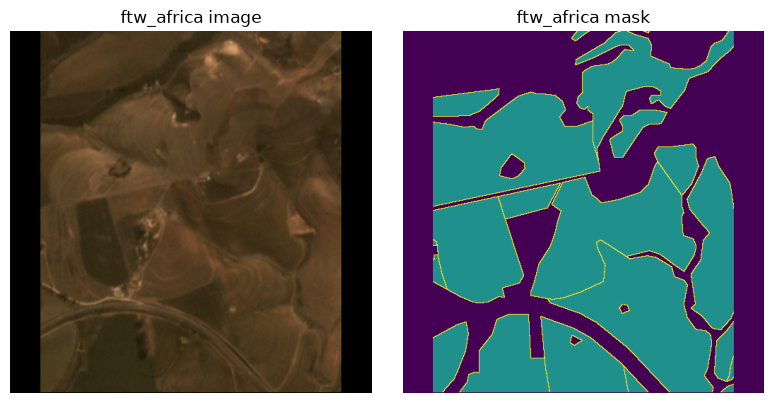

In [5]:
dataset_bundles = {}
dataset_rows = []

for dataset_name in dataset_names:
    cfg = load_yaml(dataset_config_path(dataset_name))
    splits = {split: build_dataset(cfg, split=split) for split in ['train', 'val', 'test']}
    dataset_bundles[dataset_name] = {'cfg': cfg, 'splits': splits}
    for split, ds in splits.items():
        sample = ds[0]
        dataset_rows.append({
            'dataset': dataset_name,
            'split': split,
            'n': len(ds),
            'sample_id': sample['id'],
            'x_shape': tuple(sample['x'].shape),
            'y_shape': tuple(np.asarray(sample['y']).shape),
            'mask_classes': sorted(np.unique(sample['y']).tolist()),
        })

display(pd.DataFrame(dataset_rows))

fig, axes = plt.subplots(len(dataset_names), 2, figsize=(8, 4 * len(dataset_names)))
if len(dataset_names) == 1:
    axes = np.asarray([axes])
for row, dataset_name in enumerate(dataset_names):
    sample = dataset_bundles[dataset_name]['splits']['train'][0]
    x = np.asarray(sample['x'])
    y = np.asarray(sample['y'])
    if dataset_name == 'ftw_africa':
        rgb = np.moveaxis(np.clip(x[[2, 1, 0]] * 3.0, 0, 1), 0, -1)
    else:
        rgb = np.moveaxis(np.clip(x[[3, 2, 1]] / max(float(x.max()), 1.0), 0, 1), 0, -1)
    axes[row, 0].imshow(rgb)
    axes[row, 0].set_title(f'{dataset_name} image')
    axes[row, 1].imshow(y, cmap='viridis')
    axes[row, 1].set_title(f'{dataset_name} mask')
    for ax in axes[row]:
        ax.axis('off')
plt.tight_layout()

## Check Repositories And Checkpoints

In [6]:
checkpoint_rows = []
for model_name in model_names:
    cfg = load_yaml(model_config_path(model_name))
    started = time.perf_counter()
    try:
        result = check_foundation_model(cfg, load_weights=LOAD_MODEL_WEIGHTS).as_dict()
        checkpoint_rows.append({
            'model': model_name,
            'ok': True,
            'seconds': time.perf_counter() - started,
            'weight_files': result.get('weight_files'),
            'checkpoint_load_ok': result.get('checkpoint_load_ok'),
            'checkpoint_summary': result.get('checkpoint_summary'),
            'error': None,
        })
    except Exception as exc:
        checkpoint_rows.append({
            'model': model_name,
            'ok': False,
            'seconds': time.perf_counter() - started,
            'weight_files': None,
            'checkpoint_load_ok': None,
            'checkpoint_summary': None,
            'error': f'{type(exc).__name__}: {exc}',
        })
checkpoint_df = pd.DataFrame(checkpoint_rows)
display(checkpoint_df)

,model,ok,seconds,weight_files,checkpoint_load_ok,checkpoint_summary,error
0,prithvi_eo_v2_300m,True,3.971948,[Prithvi_EO_V2_300M.pt],True,"{'checkpoint_type': 'dict', 'top_level_keys': ...",None
1,terramind_v1_base,True,1.718448,[TerraMind_v1_base.pt],True,"{'checkpoint_type': 'dict', 'top_level_keys': ...",None
2,terramind_v1_large,True,3.194171,[TerraMind_v1_large.pt],True,"{'checkpoint_type': 'dict', 'top_level_keys': ...",None


## Pipeline Runner

In [7]:
class LinearProbeSegmentationHead(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.head = nn.Conv2d(in_channels, num_classes, kernel_size=1)

    def forward(self, features, output_size):
        logits = self.head(features)
        return F.interpolate(logits, size=output_size, mode='bilinear', align_corners=False)


def clear_accelerator():
    gc.collect()
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
    elif DEVICE == 'mps':
        torch.mps.empty_cache() if hasattr(torch, 'mps') else None


def parameter_summary(backbone, head):
    backbone_total = sum(p.numel() for p in backbone.parameters())
    backbone_trainable = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
    head_total = sum(p.numel() for p in head.parameters())
    head_trainable = sum(p.numel() for p in head.parameters() if p.requires_grad)
    return {
        'backbone_total_params': backbone_total,
        'backbone_trainable_params': backbone_trainable,
        'head_total_params': head_total,
        'head_trainable_params': head_trainable,
        'total_trainable_params': backbone_trainable + head_trainable,
    }


def memory_summary():
    if DEVICE == 'cuda':
        return {'peak_accelerator_memory_gb': torch.cuda.max_memory_allocated() / 1024**3}
    if DEVICE == 'mps' and hasattr(torch, 'mps'):
        try:
            return {'peak_accelerator_memory_gb': torch.mps.current_allocated_memory() / 1024**3}
        except Exception:
            return {'peak_accelerator_memory_gb': None}
    return {'peak_accelerator_memory_gb': None}


def load_backbone(model_name, adapter):
    model_cfg = load_yaml(model_config_path(model_name))
    lora_cfg = experiment.get('adaptation', {}).get('lora', {})
    if model_name == 'prithvi_eo_v2_300m':
        loaded = load_prithvi_eo_v2_300m(load_weights=LOAD_MODEL_WEIGHTS, device=DEVICE, freeze=(adapter == 'linear_probe'))
        backbone = loaded.model
        metadata = {'checkpoint_path': str(loaded.checkpoint_path) if loaded.checkpoint_path else None}
        if adapter == 'lora':
            backbone = apply_prithvi_lora(
                backbone,
                rank=int(lora_cfg.get('rank', 8)),
                alpha=int(lora_cfg.get('alpha', 16)),
                dropout=float(lora_cfg.get('dropout', 0.05)),
            ).to(DEVICE)
            metadata.update({f'lora_{k}': v for k, v in lora_parameter_summary(backbone).items()})
        return backbone, metadata

    if model_cfg.get('model_family') == 'terramind':
        loaded = load_terramind_backbone(model_name, pretrained=LOAD_MODEL_WEIGHTS, device=DEVICE, freeze=(adapter == 'linear_probe'))
        backbone = loaded.model
        metadata = {'checkpoint_path': 'managed_by_terratorch', 'terramind_backbone': loaded.backbone_name}
        if adapter == 'lora':
            backbone = apply_terramind_lora(
                backbone,
                rank=int(lora_cfg.get('rank', 8)),
                alpha=int(lora_cfg.get('alpha', 16)),
                dropout=float(lora_cfg.get('dropout', 0.05)),
            ).to(DEVICE)
            metadata.update({f'lora_{k}': v for k, v in lora_parameter_summary(backbone).items()})
        return backbone, metadata

    raise ValueError(f'No backbone loader for {model_name}')


def adapt_inputs(model_name, dataset_name, x):
    if model_name == 'prithvi_eo_v2_300m':
        return adapt_batch_to_prithvi(dataset_name, x.to(DEVICE), image_size=FOUNDATION_IMAGE_SIZE)
    if model_name.startswith('terramind'):
        return {k: v.to(DEVICE) for k, v in adapt_batch_to_terramind(dataset_name, x.to(DEVICE), image_size=FOUNDATION_IMAGE_SIZE).items()}
    raise ValueError(model_name)


def extract_features(model_name, backbone, adapted_inputs):
    if model_name == 'prithvi_eo_v2_300m':
        return prithvi_feature_map(backbone, adapted_inputs)
    if model_name.startswith('terramind'):
        return terramind_feature_map(backbone, adapted_inputs)
    raise ValueError(model_name)


def run_one_cell(dataset_name, model_name, adapter, budget, seed):
    clear_accelerator()
    cfg = dataset_bundles[dataset_name]['cfg']
    train_ds = dataset_bundles[dataset_name]['splits']['train']
    val_ds = dataset_bundles[dataset_name]['splits']['val']
    indices = make_balanced_label_budget_indices(
        train_ds,
        cfg,
        budget,
        stable_seed(f'{dataset_name}:{model_name}:{adapter}:{seed}:{budget}'),
    )
    train_loader = DataLoader(
        Subset(train_ds, indices),
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        collate_fn=lambda batch: collate_segmentation(batch, image_size=FOUNDATION_IMAGE_SIZE),
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        collate_fn=lambda batch: collate_segmentation(batch, image_size=FOUNDATION_IMAGE_SIZE),
    )

    load_started = time.perf_counter()
    backbone, model_metadata = load_backbone(model_name, adapter)
    load_seconds = time.perf_counter() - load_started

    first_batch = next(iter(train_loader))
    with torch.set_grad_enabled(adapter == 'lora'):
        first_features = extract_features(model_name, backbone, adapt_inputs(model_name, dataset_name, first_batch['x']))
    head = LinearProbeSegmentationHead(first_features.shape[1], int(cfg['num_classes'])).to(DEVICE)
    optimizer = torch.optim.AdamW([p for p in list(backbone.parameters()) + list(head.parameters()) if p.requires_grad], lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    losses = []
    train_started = time.perf_counter()
    if RUN_TRAINING_STEP:
        backbone.train(adapter == 'lora')
        head.train()
        for step, batch in enumerate(train_loader):
            if PIPELINE_TEST_MODE and step >= TEST_MAX_TRAIN_BATCHES:
                break
            adapted = adapt_inputs(model_name, dataset_name, batch['x'])
            y = batch['y'].to(DEVICE)
            with torch.set_grad_enabled(adapter == 'lora'):
                features = extract_features(model_name, backbone, adapted)
            logits = head(features, output_size=y.shape[-2:])
            loss = criterion(logits, y)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            losses.append(float(loss.detach().cpu()))
    train_seconds = time.perf_counter() - train_started

    y_true, y_pred = [], []
    backbone.eval()
    head.eval()
    with torch.no_grad():
        for step, batch in enumerate(val_loader):
            if PIPELINE_TEST_MODE and step >= TEST_MAX_VAL_BATCHES:
                break
            adapted = adapt_inputs(model_name, dataset_name, batch['x'])
            features = extract_features(model_name, backbone, adapted)
            logits = head(features, output_size=batch['y'].shape[-2:])
            y_true.append(batch['y'].numpy())
            y_pred.append(logits.argmax(dim=1).cpu().numpy())
    metrics = segmentation_metrics(
        np.concatenate(y_true, axis=0),
        np.concatenate(y_pred, axis=0),
        int(cfg['num_classes']),
        class_names=cfg.get('class_names'),
    )

    row = {
        'dataset': dataset_name,
        'model': model_name,
        'adapter': adapter,
        'label_budget': budget,
        'seed': seed,
        'ok': True,
        'device': DEVICE,
        'num_train_examples': len(indices),
        'batch_size': batch_size,
        'foundation_image_size': FOUNDATION_IMAGE_SIZE,
        'feature_shape': tuple(first_features.shape),
        'model_load_seconds': load_seconds,
        'train_seconds': train_seconds,
        'train_batches': len(losses),
        'train_loss_last': losses[-1] if losses else None,
        **parameter_summary(backbone, head),
        **memory_summary(),
        **model_metadata,
        **metrics,
    }
    del backbone, head, optimizer, first_features
    clear_accelerator()
    return row

## Run Tiny Full Matrix

In [8]:
results = []
for dataset_name in dataset_names:
    for model_name in model_names:
        for adapter in adaptation_methods:
            for budget in label_budgets:
                for seed in seeds:
                    print(f'RUN {dataset_name} | {model_name} | {adapter} | budget={budget} | seed={seed}')
                    started = time.perf_counter()
                    try:
                        row = run_one_cell(dataset_name, model_name, adapter, budget, seed)
                        row['wall_seconds'] = time.perf_counter() - started
                    except Exception as exc:
                        row = {
                            'dataset': dataset_name,
                            'model': model_name,
                            'adapter': adapter,
                            'label_budget': budget,
                            'seed': seed,
                            'ok': False,
                            'error': f'{type(exc).__name__}: {exc}',
                            'wall_seconds': time.perf_counter() - started,
                        }
                        print('FAILED:', row['error'])
                        clear_accelerator()
                        if RAISE_ON_FIRST_FAILURE:
                            raise
                    results.append(row)
                    display(pd.DataFrame([row]))

results_df = pd.DataFrame(results)
display(results_df)

RUN ftw_africa | prithvi_eo_v2_300m | linear_probe | budget=0.1 | seed=1234


,dataset,model,adapter,label_budget,seed,ok,device,num_train_examples,batch_size,foundation_image_size,...,peak_accelerator_memory_gb,checkpoint_path,iou_background,iou_field_interior,iou_field_boundary,iou,mean_iou,pixel_accuracy,foreground_iou,wall_seconds
0,ftw_africa,prithvi_eo_v2_300m,linear_probe,0.1,1234,True,mps,80,1,224,...,1.257057,/Users/similoluwaokunowo/Desktop/Research/geoa...,0.721025,0.437385,0.0,0.386137,0.386137,0.766539,0.218692,11.977132


RUN ftw_africa | prithvi_eo_v2_300m | linear_probe | budget=0.25 | seed=1234


,dataset,model,adapter,label_budget,seed,ok,device,num_train_examples,batch_size,foundation_image_size,...,peak_accelerator_memory_gb,checkpoint_path,iou_background,iou_field_interior,iou_field_boundary,iou,mean_iou,pixel_accuracy,foreground_iou,wall_seconds
0,ftw_africa,prithvi_eo_v2_300m,linear_probe,0.25,1234,True,mps,199,1,224,...,1.257057,/Users/similoluwaokunowo/Desktop/Research/geoa...,0.593836,0.31141,0.0,0.301749,0.301749,0.653564,0.155705,11.197536


RUN ftw_africa | prithvi_eo_v2_300m | lora | budget=0.1 | seed=1234


...

RUN ftw_africa | terramind_v1_large | lora | budget=0.1 | seed=1234


,dataset,model,adapter,label_budget,seed,ok,device,num_train_examples,batch_size,foundation_image_size,...,lora_trainable_params,lora_trainable_fraction,iou_background,iou_field_interior,iou_field_boundary,iou,mean_iou,pixel_accuracy,foreground_iou,wall_seconds
0,ftw_africa,terramind_v1_large,lora,0.1,1234,True,mps,80,1,224,...,2641664,0.008627,0.192334,0.353225,0.0,0.181853,0.181853,0.437933,0.176613,10.126277


RUN ftw_africa | terramind_v1_large | lora | budget=0.25 | seed=1234


,dataset,model,adapter,label_budget,seed,ok,device,num_train_examples,batch_size,foundation_image_size,...,lora_trainable_params,lora_trainable_fraction,iou_background,iou_field_interior,iou_field_boundary,iou,mean_iou,pixel_accuracy,foreground_iou,wall_seconds
0,ftw_africa,terramind_v1_large,lora,0.25,1234,True,mps,199,1,224,...,2641664,0.008627,0.769998,0.571283,0.0,0.447094,0.447094,0.819351,0.285642,9.829668


,dataset,model,adapter,label_budget,seed,ok,device,num_train_examples,batch_size,foundation_image_size,...,iou_field_boundary,iou,mean_iou,pixel_accuracy,foreground_iou,wall_seconds,lora_total_params,lora_trainable_params,lora_trainable_fraction,terramind_backbone
0,ftw_africa,prithvi_eo_v2_300m,linear_probe,0.10,1234,True,mps,80,1,224,...,0.0,0.386137,0.386137,0.766539,0.218692,11.977132,NaN,NaN,NaN,NaN
1,ftw_africa,prithvi_eo_v2_300m,linear_probe,0.25,1234,True,mps,199,1,224,...,0.0,0.301749,0.301749,0.653564,0.155705,11.197536,NaN,NaN,NaN,NaN
2,ftw_africa,prithvi_eo_v2_300m,lora,0.10,1234,True,mps,80,1,224,...,0.0,0.484725,0.484725,0.849430,0.326586,18.895519,334110208.0,3690496.0,0.011046,NaN
3,ftw_africa,prithvi_eo_v2_300m,lora,0.25,1234,True,mps,199,1,224,...,0.0,0.428407,0.428407,0.792224,0.278448,15.447822,334110208.0,3690496.0,0.011046,NaN
4,ftw_africa,terramind_v1_base,linear_probe,0.10,1234,True,mps,80,1,224,...,0.0,0.166872,0.166872,0.417177,0.176714,8.722620,NaN,NaN,NaN,terramind_v1_base
5,ftw_africa,terramind_v1_base,linear_probe,0.25,1234,True,mps,199,1,224,...,0.0,0.162854,0.162854,0.410772,0.175467,5.168668,NaN,NaN,NaN,terramind_v1_base
6,ftw_africa,terramind_v1_base,lora,0.10,1234,True,mps,80,1,224,...,0.0,0.172443,0.172443,0.423126,0.174107,5.681630,87135744.0,1001472.0,0.011493,terramind_v1_base
7,ftw_africa,terramind_v1_base,lora,0.25,1234,True,mps,199,1,224,...,0.0,0.172901,0.172901,0.423900,0.174311,6.042569,87135744.0,1001472.0,0.011493,terramind_v1_base
8,ftw_africa,terramind_v1_large,linear_probe,0.10,1234,True,mps,80,1,224,...,0.0,0.172415,0.172415,0.424421,0.176151,10.006492,NaN,NaN,NaN,terramind_v1_large
9,ftw_africa,terramind_v1_large,linear_probe,0.25,1234,True,mps,199,1,224,...,0.0,0.174522,0.174522,0.426783,0.175237,8.740433,NaN,NaN,NaN,terramind_v1_large


## Readiness Summary

In [9]:
readiness = (
    results_df
    .assign(status=lambda df: np.where(df['ok'], 'runnable', 'failed'))
    .groupby(['dataset', 'model', 'adapter', 'status'], dropna=False)
    .size()
    .reset_index(name='n')
)
display(readiness)

if 'ok' in results_df:
    print(results_df['ok'].value_counts(dropna=False))
    failed = results_df[results_df['ok'] == False]
    if len(failed):
        display(failed[['dataset', 'model', 'adapter', 'error']])

,dataset,model,adapter,status,n
0,ftw_africa,prithvi_eo_v2_300m,linear_probe,runnable,2
1,ftw_africa,prithvi_eo_v2_300m,lora,runnable,2
2,ftw_africa,terramind_v1_base,linear_probe,runnable,2
3,ftw_africa,terramind_v1_base,lora,runnable,2
4,ftw_africa,terramind_v1_large,linear_probe,runnable,2
5,ftw_africa,terramind_v1_large,lora,runnable,2


ok
True    12
Name: count, dtype: int64


## Save Artifacts

In [10]:
artifact_dir = PROJECT_ROOT / 'artifacts' / RUN_LABEL
artifact_dir.mkdir(parents=True, exist_ok=True)

results_path = artifact_dir / 'results.jsonl'
summary_path = artifact_dir / 'summary.json'
readiness_path = artifact_dir / 'readiness.csv'

results_df.to_json(results_path, orient='records', lines=True)
readiness.to_csv(readiness_path, index=False)
with summary_path.open('w', encoding='utf-8') as handle:
    json.dump({
        'hardware': hardware,
        'experiment': experiment,
        'pipeline_test_mode': PIPELINE_TEST_MODE,
        'run_label': RUN_LABEL,
        'dataset_names': dataset_names,
        'model_names': model_names,
        'adaptation_methods': adaptation_methods,
        'label_budgets': label_budgets,
        'seeds': seeds,
        'max_train_batches': TEST_MAX_TRAIN_BATCHES if PIPELINE_TEST_MODE else None,
        'max_val_batches': TEST_MAX_VAL_BATCHES if PIPELINE_TEST_MODE else None,
        'checkpoint_rows': checkpoint_df.to_dict('records'),
        'results_path': str(results_path),
        'readiness_path': str(readiness_path),
    }, handle, indent=2, default=str)

{'results': str(results_path), 'readiness': str(readiness_path), 'summary': str(summary_path)}

{'results': '/Users/similoluwaokunowo/Desktop/Research/geoai-lightning-talk-research/artifacts/ftw_mac_pilot_v1/results.jsonl',
 'readiness': '/Users/similoluwaokunowo/Desktop/Research/geoai-lightning-talk-research/artifacts/ftw_mac_pilot_v1/readiness.csv',
 'summary': '/Users/similoluwaokunowo/Desktop/Research/geoai-lightning-talk-research/artifacts/ftw_mac_pilot_v1/summary.json'}

## Interpreting This Notebook

If a row fails because `terratorch` is missing, restart the kernel and run the import/setup cell again. That cell installs `terratorch==1.2.8` into the active notebook kernel when needed.

If TerraMind-large fails on L4 due to memory, that is a useful result: keep L4 for Prithvi/base integration and move the large model to A100 for the full matrix.

After every row passes in `PIPELINE_TEST_MODE = True`, increase budgets/seeds or set `PIPELINE_TEST_MODE = False`.